# 01 — Baseline sanity check: repo TPE

Чистый baseline-ноутбук для сравнения:

- `random` — `RandomSearch` из repo;
- `no_w` — `TPEOptimizer` из repo без `weight_fn`;
- `optuna` — reference baseline, если импорт доступен.

В ноутбуке оставлены только нужные для анализа метрики:

- расстояние по аргументу до истинного минимума: `dist_x`;
- ошибка по значению функции: `dist_y`;
- количество шагов до порога;
- матожидание и дисперсия по 30 запускам;
- графики среднего `dist_x` и `dist_y` по итерациям;
- карта выбора точек для понимания поведения алгоритма.

Функции clean и non-normalized. Импорты и настройка Google Drive не изменяются.


In [ ]:
# ============================================================
# ЯЧЕЙКА 1: Установка зависимостей
# ============================================================
!pip uninstall -y ConfigSpace
!pip install -U "ConfigSpace==1.2.0"
!pip -q install parzen-estimator numpy matplotlib optuna

Found existing installation: ConfigSpace 1.2.0
Uninstalling ConfigSpace-1.2.0:
  Successfully uninstalled ConfigSpace-1.2.0
  Using cached configspace-1.2.0-py3-none-any.whl


In [ ]:
# ============================================================
# ЯЧЕЙКА 1: Импорты и путь к repo
# ВАЖНО: блок повторяет твой рабочий ноутбук.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
import sys
import pandas as pd
import math

import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH

try:
    import optuna
    from optuna.samplers import TPESampler
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except Exception as e:
    HAS_OPTUNA = False
    print("Optuna не импортировалась:", repr(e))

# ------------------------------------------------------------
# Патч ConfigSpace — как в твоём рабочем ноутбуке
# ------------------------------------------------------------

def _q_prop(self):
    return getattr(self, "_q", None)

_NEED_Q = [
    "UniformFloatHyperparameter",
    "UniformIntegerHyperparameter",
    "NormalFloatHyperparameter",
    "NormalIntegerHyperparameter",
]

for name in _NEED_Q:
    cls = getattr(CSH, name, None)
    if cls is not None and not hasattr(cls, "q"):
        setattr(cls, "q", property(_q_prop))

# ------------------------------------------------------------
# Google Drive — как в твоём рабочем ноутбуке
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", repr(e))

# ------------------------------------------------------------
# ВАЖНО:
# В твоём рабочем ноутбуке был именно этот путь:
# TPE_ROOT = Path("drive/MyDrive/content")
#
# Добавляем в sys.path ТОЛЬКО TPE_ROOT.
# НЕ добавляем TPE_ROOT/tpe и TPE_ROOT/tpe/optimizer,
# иначе возникает ошибка:
# 'tpe' is not a package.
# ------------------------------------------------------------

TPE_ROOT = Path("drive/MyDrive/content")

if not (TPE_ROOT / "tpe").exists():
    alt = Path("/content/drive/MyDrive/content")
    if (alt / "tpe").exists():
        TPE_ROOT = alt

if not (TPE_ROOT / "tpe").exists():
    raise FileNotFoundError(
        f"Не найдена папка repo: {TPE_ROOT / 'tpe'}"
    )

if str(TPE_ROOT) not in sys.path:
    sys.path.append(str(TPE_ROOT))

# Если в текущем kernel раньше был сломанный импорт tpe,
# чистим кэш модулей.
for key in list(sys.modules.keys()):
    if key == "tpe" or key.startswith("tpe."):
        del sys.modules[key]

(TPE_ROOT / "tpe" / "__init__.py").touch(exist_ok=True)

from tpe.optimizer.tpe_optimizer import TPEOptimizer
from tpe.optimizer.random_search import RandomSearch

print("TPE_ROOT =", TPE_ROOT)
print("Импорт успешен")
print("HAS_OPTUNA =", HAS_OPTUNA)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TPE_ROOT = drive/MyDrive/content
Импорт успешен
HAS_OPTUNA = True


# 2. Clean non-normalized functions

In [ ]:
def sphere_raw(x):
    x = np.asarray(x, dtype=float)
    return float(np.sum(x ** 2))


def rosenbrock_raw(x):
    x = np.asarray(x, dtype=float)
    return float(
        np.sum(
            100.0 * (x[1:] - x[:-1] ** 2) ** 2
            + (1.0 - x[:-1]) ** 2
        )
    )


def rastrigin_raw(x):
    x = np.asarray(x, dtype=float)
    d = len(x)
    return float(
        10.0 * d + np.sum(x ** 2 - 10.0 * np.cos(2.0 * np.pi * x))
    )


def ackley_raw(x):
    x = np.asarray(x, dtype=float)
    d = len(x)
    a = 20.0
    b = 0.2
    c = 2.0 * np.pi
    s1 = np.sum(x ** 2)
    s2 = np.sum(np.cos(c * x))
    return float(
        -a * np.exp(-b * np.sqrt(s1 / d))
        - np.exp(s2 / d)
        + a
        + np.e
    )


CLEAN_MAP = {
    "Sphere(2D)": sphere_raw,
    "Rosenbrock(2D)": rosenbrock_raw,
    "Rastrigin(2D)": rastrigin_raw,
    "Ackley(2D)": ackley_raw,
}

FUNC_MAP = CLEAN_MAP.copy()

TRUE_MINIMA = {
    "Sphere(2D)": np.array([0.0, 0.0]),
    "Rosenbrock(2D)": np.array([1.0, 1.0]),
    "Rastrigin(2D)": np.array([0.0, 0.0]),
    "Ackley(2D)": np.array([0.0, 0.0]),
}


# 3. ConfigSpace

In [ ]:
def make_cs(bounds, seed=0):
    cs = CS.ConfigurationSpace(seed=seed)
    hps = [
        CSH.UniformFloatHyperparameter(name, lower=lo, upper=hi)
        for name, lo, hi in bounds
    ]
    cs.add_hyperparameters(hps)
    return cs


CS_MAP = {
    "Sphere(2D)":     make_cs([("x0", -5.0, 5.0), ("x1", -5.0, 5.0)], seed=0),
    "Rosenbrock(2D)": make_cs([("x0", -2.0, 2.0), ("x1", -1.0, 3.0)], seed=0),
    "Rastrigin(2D)":  make_cs([("x0", -5.12, 5.12), ("x1", -5.12, 5.12)], seed=0),
    "Ackley(2D)":     make_cs([("x0", -5.0, 5.0), ("x1", -5.0, 5.0)], seed=0),
}


# 4. Settings

In [ ]:
SEEDS = tuple(range(30))

N_INIT = 25
MAX_EVALS = 100

BASE_KWARGS = dict(
    n_ei_candidates=24,
    min_bandwidth_factor=1e-2,
    top=0.2,
)

THRESHOLDS = {
    "Sphere(2D)":     1e-2,
    "Rosenbrock(2D)": 1e-1,
    "Rastrigin(2D)":  2e-0,
    "Ackley(2D)":     5e-1,
}

RESULTS_ROOT = Path(".tpe_results_01_baseline")
RESULTS_ROOT.mkdir(exist_ok=True)

print("SEEDS =", len(SEEDS))
print("MAX_EVALS =", MAX_EVALS)


SEEDS = 30
MAX_EVALS = 100


# 5. Runner через repo optimizer

In [ ]:
def running_best(losses):
    """Возвращает best-so-far кривую: минимум среди всех наблюдений до текущей итерации."""
    best, cur = [], float("inf")
    for v in losses:
        cur = min(cur, float(v))
        best.append(cur)
    return np.array(best, dtype=float)


def build_curves_from_history(x_history, losses, fn_name, clean_fn):
    """
    Строит все нужные кривые по истории выбранных точек.

    Важно:
    - x_history — все точки, которые алгоритм реально проверил;
    - losses — наблюдаемые значения функции;
    - best_x_history — лучшая найденная точка на каждой итерации;
    - dist_x_curve[t] = ||x_best(t) - x*||_2;
    - dist_y_curve[t] = |f_clean(x_best(t)) - f_clean(x*)|.

    Для clean-функций в этом ноутбуке f_clean(x*) = 0.
    """
    true_min = TRUE_MINIMA[fn_name]
    f_min = float(clean_fn(true_min))

    best_observed = float("inf")
    best_x = None

    best_x_history = []
    clean_best_curve = []
    dist_x_curve = []
    dist_y_curve = []

    for x, loss in zip(x_history, losses):
        x = np.asarray(x, dtype=float)
        loss = float(loss)

        if loss < best_observed:
            best_observed = loss
            best_x = x.copy()

        clean_value = float(clean_fn(best_x))

        best_x_history.append(best_x.copy())
        clean_best_curve.append(clean_value)
        dist_x_curve.append(float(np.linalg.norm(best_x - true_min)))
        dist_y_curve.append(float(abs(clean_value - f_min)))

    return {
        "x_history": np.asarray(x_history, dtype=float),
        "best_x_history": np.asarray(best_x_history, dtype=float),
        "losses": np.asarray(losses, dtype=float),
        "best_curve": running_best(losses),
        "clean_curve": np.asarray(clean_best_curve, dtype=float),
        "dist_x_curve": np.asarray(dist_x_curve, dtype=float),
        "dist_y_curve": np.asarray(dist_y_curve, dtype=float),
    }


def run_once(OptClass, obj_func, cs, *, seed, n_init=10, max_evals=60,
             tpe_kwargs=None, fn_name=None, clean_fn=None):
    """Один запуск repo-оптимизатора: random или TPE."""

    tpe_kwargs = tpe_kwargs or {}

    task = fn_name or "task"
    algo = "tpe" if OptClass is TPEOptimizer else "random"

    out_dir = RESULTS_ROOT / str(task)
    out_dir.mkdir(parents=True, exist_ok=True)

    resultfile = str(out_dir / f"{algo}_seed{seed}")

    if OptClass is TPEOptimizer:
        opt = OptClass(
            obj_func=obj_func,
            config_space=cs,
            resultfile=resultfile,
            n_init=n_init,
            max_evals=max_evals,
            seed=seed,
            metric_name="loss",
            **tpe_kwargs,
        )
    else:
        opt = OptClass(
            obj_func=obj_func,
            config_space=cs,
            resultfile=resultfile,
            n_init=n_init,
            max_evals=max_evals,
            seed=seed,
            metric_name="loss",
        )

    best_cfg, best_loss = opt.optimize()
    obs = opt.fetch_observations()

    losses = np.asarray(obs["loss"], dtype=float)
    x_history = np.column_stack([
        np.asarray(obs["x0"], dtype=float),
        np.asarray(obs["x1"], dtype=float),
    ])

    result = build_curves_from_history(
        x_history=x_history,
        losses=losses,
        fn_name=fn_name,
        clean_fn=clean_fn,
    )

    result.update({
        "best_cfg": best_cfg,
        "best_loss": float(best_loss),
    })

    return result


def run_benchmark(fn_name, seeds, n_init=10, max_evals=60, tpe_kwargs=None):
    """Запускает random и repo TPE на одной функции для всех seed."""
    fn = FUNC_MAP[fn_name]
    clean_fn = CLEAN_MAP[fn_name]
    cs = CS_MAP[fn_name]

    obj_func_instance = lambda cfg: (
        {"loss": float(fn(np.array([cfg["x0"], cfg["x1"]], dtype=float)))},
        0.0,
    )

    out = {
        "random": [],
        "tpe": [],
    }

    for s in seeds:
        out["random"].append(
            run_once(
                RandomSearch,
                obj_func_instance,
                cs,
                seed=s,
                n_init=n_init,
                max_evals=max_evals,
                fn_name=fn_name,
                clean_fn=clean_fn,
            )
        )

        out["tpe"].append(
            run_once(
                TPEOptimizer,
                obj_func_instance,
                cs,
                seed=s,
                n_init=n_init,
                max_evals=max_evals,
                tpe_kwargs=tpe_kwargs,
                fn_name=fn_name,
                clean_fn=clean_fn,
            )
        )

    return out


# 6. Optuna reference

In [ ]:
def run_optuna_tpe(fn_name, seed, n_trials=60):
    """Reference TPE из Optuna. Используется только если Optuna импортировалась."""
    if not HAS_OPTUNA:
        return None

    clean_fn = CLEAN_MAP[fn_name]
    fn = FUNC_MAP[fn_name]

    bounds = {
        "Sphere(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
        "Rosenbrock(2D)": [(-2.0, 2.0), (-1.0, 3.0)],
        "Rastrigin(2D)":  [(-5.12, 5.12), (-5.12, 5.12)],
        "Ackley(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
    }[fn_name]

    sampler = TPESampler(
        seed=seed,
        n_startup_trials=N_INIT,
        n_ei_candidates=BASE_KWARGS["n_ei_candidates"],
    )

    study = optuna.create_study(direction="minimize", sampler=sampler)

    losses = []
    x_history = []

    def objective(trial):
        x0 = trial.suggest_float("x0", bounds[0][0], bounds[0][1])
        x1 = trial.suggest_float("x1", bounds[1][0], bounds[1][1])
        x = np.array([x0, x1], dtype=float)

        loss = float(fn(x))
        losses.append(loss)
        x_history.append(x.copy())

        return loss

    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    result = build_curves_from_history(
        x_history=np.asarray(x_history, dtype=float),
        losses=np.asarray(losses, dtype=float),
        fn_name=fn_name,
        clean_fn=clean_fn,
    )

    result.update({
        "best_loss": float(study.best_value),
    })

    return result


# 7. Run experiment

In [ ]:
all_results = {}

start_time = time.time()

for fn_name in FUNC_MAP.keys():
    print(f"\n{'=' * 60}")
    print(f"Функция: {fn_name}")
    print(f"{'=' * 60}")

    res = run_benchmark(
        fn_name,
        seeds=SEEDS,
        n_init=N_INIT,
        max_evals=MAX_EVALS,
        tpe_kwargs=BASE_KWARGS,
    )

    all_results[fn_name] = {
        "random": res["random"],
        "no_w": res["tpe"],
    }

    if HAS_OPTUNA:
        print("Optuna...")
        all_results[fn_name]["optuna"] = [
            run_optuna_tpe(fn_name, seed=s, n_trials=MAX_EVALS)
            for s in SEEDS
        ]

elapsed = time.time() - start_time

print(f"\nГотово. Время: {elapsed:.2f} секунд")



Функция: Sphere(2D)
Optuna...

Функция: Rosenbrock(2D)
Optuna...

Функция: Rastrigin(2D)
Optuna...

Функция: Ackley(2D)
Optuna...

Готово. Время: 85.64 секунд


# 8. Summary table

Итоговая таблица содержит только нужные метрики:

- `steps_mean`, `steps_var` — матожидание и дисперсия числа шагов до порога среди успешных запусков;
- `success_rate_%` — доля запусков, достигших порога;
- `final_dist_x_mean`, `final_dist_x_var` — матожидание и дисперсия финального расстояния до минимума по аргументу;
- `final_dist_y_mean`, `final_dist_y_var` — матожидание и дисперсия финальной ошибки по значению функции;
- `seed_i_steps` — число шагов до порога по каждому seed; `NaN`, если порог не достигнут.


In [ ]:
rows = []

for fn_name in FUNC_MAP.keys():
    threshold = THRESHOLDS[fn_name]

    for variant, runs in all_results[fn_name].items():
        # Шаг до порога считаем по dist_y, то есть по ошибке clean-функции.
        # Это честнее, чем считать по noisy loss, потому что шум может случайно дать хорошее значение.
        steps_to_threshold = []
        final_dist_x = []
        final_dist_y = []

        for r in runs:
            step = next(
                (i + 1 for i, v in enumerate(r["dist_y_curve"]) if v <= threshold),
                np.nan,
            )

            steps_to_threshold.append(step)
            final_dist_x.append(float(r["dist_x_curve"][-1]))
            final_dist_y.append(float(r["dist_y_curve"][-1]))

        successful_steps = [s for s in steps_to_threshold if not pd.isna(s)]

        row = {
            "function": fn_name,
            "variant": variant,
            "threshold_y": threshold,
            "success_rate_%": 100.0 * len(successful_steps) / len(steps_to_threshold),
            "steps_mean": float(np.mean(successful_steps)) if successful_steps else np.nan,
            "steps_var": float(np.var(successful_steps)) if successful_steps else np.nan,
            "final_dist_x_mean": float(np.mean(final_dist_x)),
            "final_dist_x_var": float(np.var(final_dist_x)),
            "final_dist_y_mean": float(np.mean(final_dist_y)),
            "final_dist_y_var": float(np.var(final_dist_y)),
        }

        for i, s in enumerate(steps_to_threshold):
            row[f"seed_{i}_steps"] = s

        rows.append(row)

seed_cols = [f"seed_{i}_steps" for i in range(len(SEEDS))]

base_cols = [
    "function",
    "variant",
    "threshold_y",
    "success_rate_%",
    "steps_mean",
    "steps_var",
    "final_dist_x_mean",
    "final_dist_x_var",
    "final_dist_y_mean",
    "final_dist_y_var",
]

df_summary = pd.DataFrame(rows)[base_cols + seed_cols]
df_summary = df_summary.sort_values(["function", "final_dist_y_mean", "final_dist_x_mean"])

df_summary


,function,variant,threshold_y,success_rate_%,steps_mean,steps_var,final_dist_x_mean,final_dist_x_var,final_dist_y_mean,final_dist_y_var,...,seed_20_steps,seed_21_steps,seed_22_steps,seed_23_steps,seed_24_steps,seed_25_steps,seed_26_steps,seed_27_steps,seed_28_steps,seed_29_steps
11,Ackley(2D),optuna,0.50,36.666667,61.909091,250.628099,0.119094,0.002841,0.714976,0.172759,...,92.0,NaN,NaN,NaN,62.0,72.0,NaN,NaN,43.0,NaN
10,Ackley(2D),no_w,0.50,23.333333,63.571429,341.959184,0.680907,0.211658,1.970420,1.313111,...,78.0,NaN,46.0,NaN,NaN,47.0,NaN,NaN,NaN,100.0
9,Ackley(2D),random,0.50,3.333333,56.000000,0.000000,0.584555,0.103910,2.843320,1.071850,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Rastrigin(2D),optuna,2.00,36.666667,67.363636,302.413223,0.950815,0.277434,2.384443,1.043560,...,NaN,NaN,NaN,NaN,69.0,72.0,94.0,87.0,52.0,40.0
7,Rastrigin(2D),no_w,2.00,56.666667,47.176471,431.792388,1.282781,0.610324,2.483579,5.955248,...,91.0,NaN,49.0,26.0,NaN,47.0,NaN,36.0,31.0,84.0
6,Rastrigin(2D),random,2.00,3.333333,56.000000,0.000000,1.526490,0.746594,6.289592,8.928979,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Rosenbrock(2D),optuna,0.10,30.000000,52.444444,788.691358,0.702005,0.178382,0.314340,0.260305,...,93.0,72.0,NaN,NaN,NaN,29.0,86.0,18.0,NaN,14.0
4,Rosenbrock(2D),no_w,0.10,53.333333,41.875000,356.234375,0.696168,0.303922,0.349909,0.872659,...,78.0,NaN,NaN,NaN,58.0,42.0,NaN,18.0,27.0,14.0
3,Rosenbrock(2D),random,0.10,23.333333,39.571429,371.387755,0.649091,0.243777,0.535861,0.522177,...,NaN,NaN,72.0,45.0,NaN,NaN,NaN,18.0,NaN,14.0
2,Sphere(2D),optuna,0.01,43.333333,64.076923,323.917160,0.118077,0.004668,0.018610,0.000450,...,NaN,NaN,69.0,NaN,NaN,84.0,34.0,NaN,NaN,NaN


In [ ]:
out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

summary_path = out_dir / "01_baseline_summary_clean.csv"
df_summary.to_csv(summary_path, index=False)

print("Saved:", summary_path)


Saved: results/01_baseline_summary_clean.csv


# 9. Necessary plots

Оставляем только нужные графики:

1. среднее расстояние до минимума по аргументу `dist_x`;
2. средняя ошибка по значению функции `dist_y`;
3. карта выбора точек алгоритмом: contour функции + реальные выбранные точки + траектория + истинный минимум.

Первые два графика строятся по best-so-far точке, то есть по лучшей найденной точке на каждой итерации. Карта выбора точек строится по фактически выбранным точкам `x_history`.


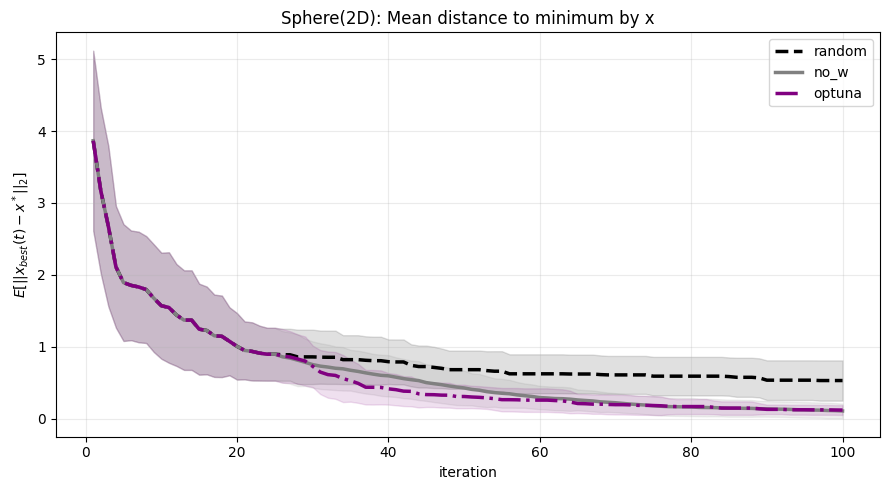

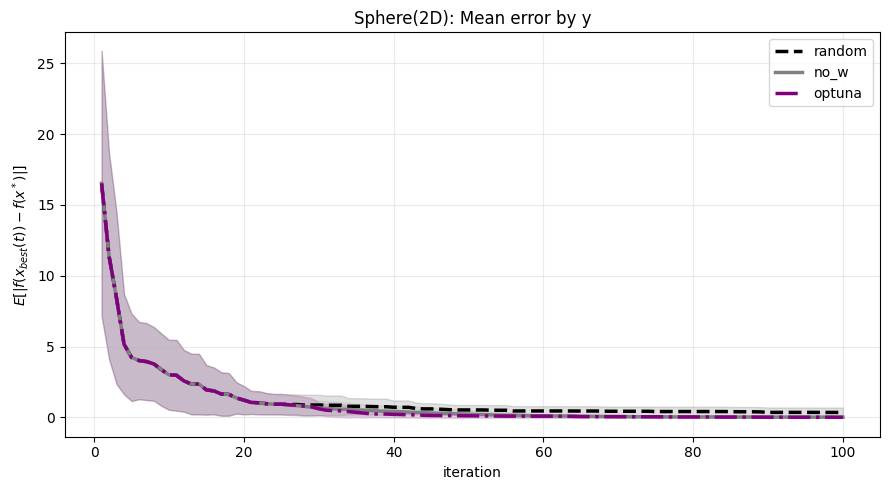

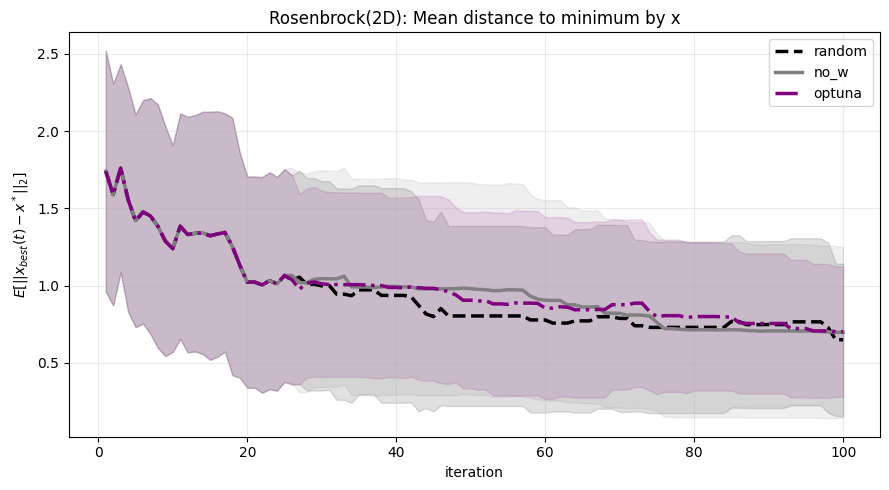

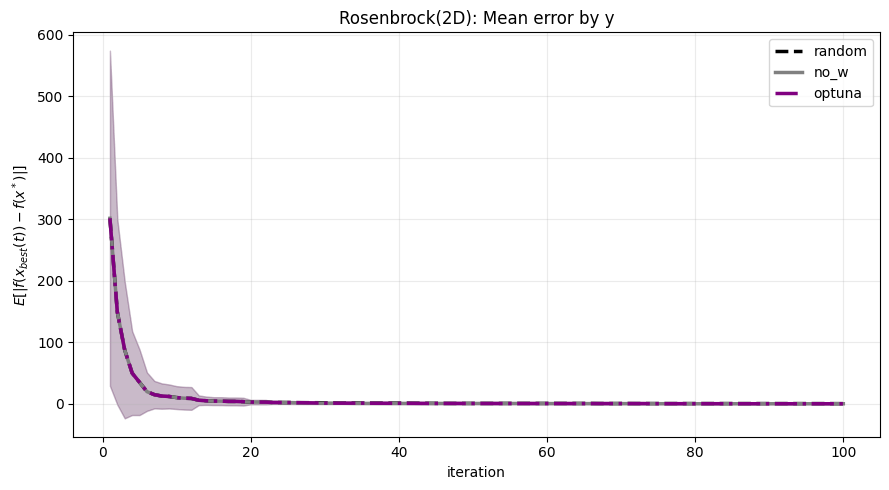

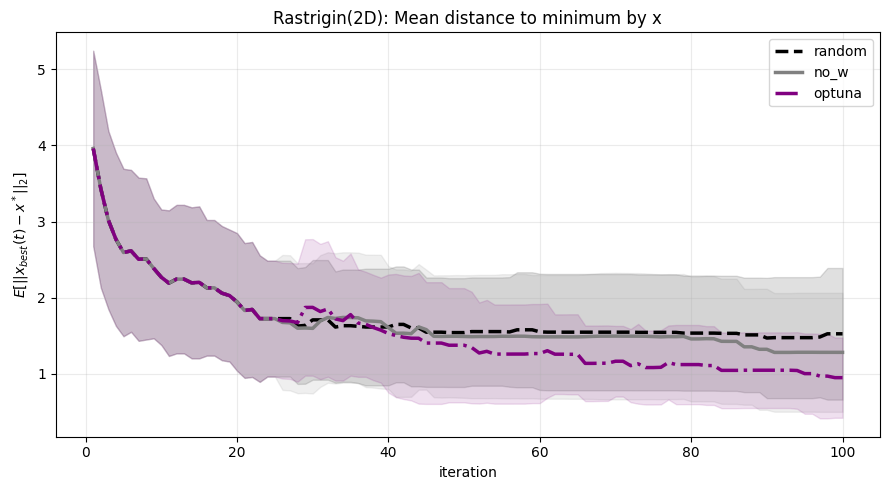

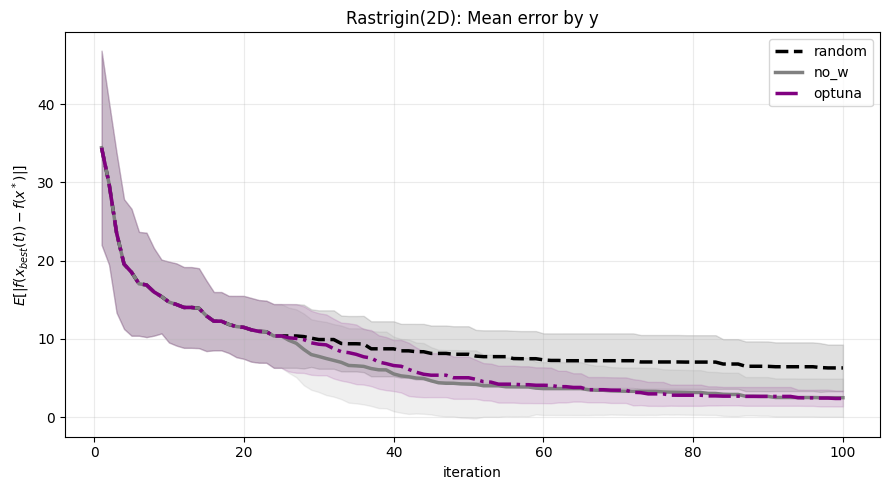

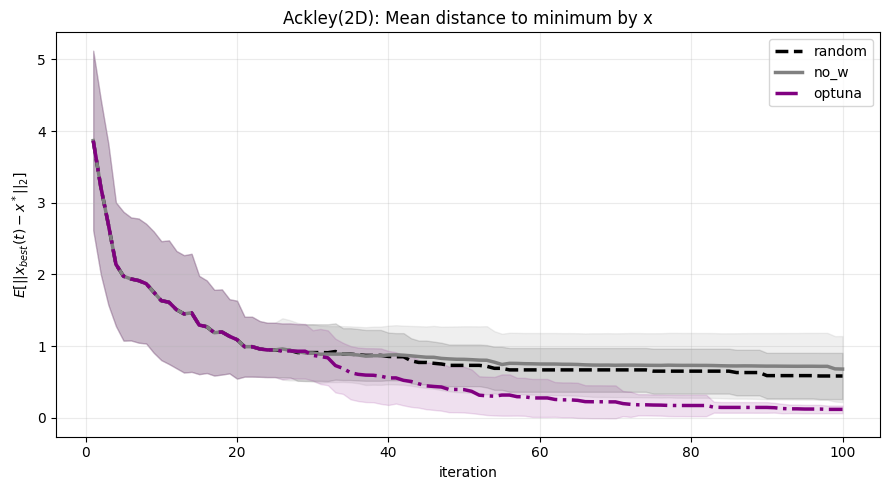

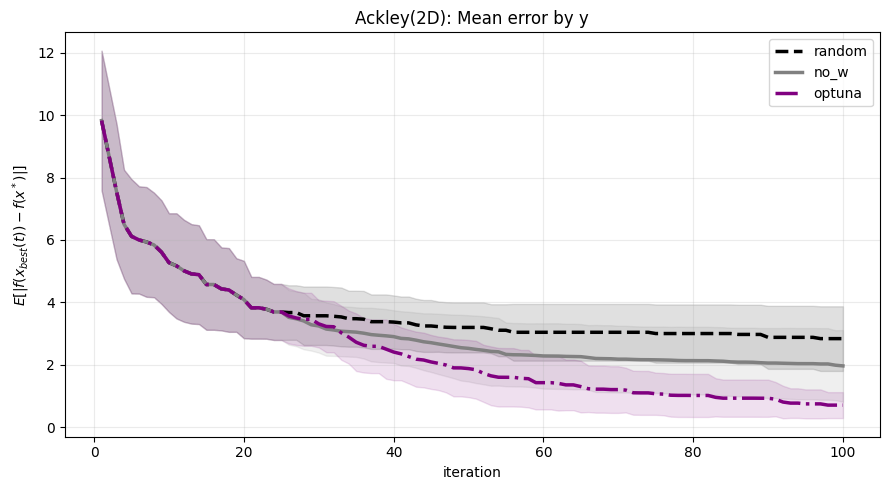

In [ ]:
VARIANT_STYLES = {
    "random": ("black", "--", 2.5),
    "no_w": ("gray", "-", 2.5),
    "optuna": ("purple", "-.", 2.5),
}


def mean_and_var_curve(runs, metric):
    """Матожидание и дисперсия кривой по seed на каждой итерации."""
    curves = np.vstack([r[metric] for r in runs])
    return curves.mean(axis=0), curves.var(axis=0)


def plot_mean_metric_curves(fn_name, results_for_fn):
    """
    Два основных графика:
    - E[dist_x(t)] — среднее расстояние до истинного минимума по аргументу;
    - E[dist_y(t)] — средняя ошибка по значению функции.

    Полупрозрачная область вокруг линии — стандартное отклонение по seed.
    """
    plots = [
        ("dist_x_curve", "Mean distance to minimum by x", r"$E[||x_{best}(t)-x^*||_2]$"),
        ("dist_y_curve", "Mean error by y", r"$E[|f(x_{best}(t))-f(x^*)|]$"),
    ]

    for metric, title, ylabel in plots:
        plt.figure(figsize=(9, 5))
        plt.title(f"{fn_name}: {title}")
        plt.xlabel("iteration")
        plt.ylabel(ylabel)

        for variant, runs in results_for_fn.items():
            color, ls, lw = VARIANT_STYLES.get(variant, (None, "-", 2.0))
            mean, var = mean_and_var_curve(runs, metric)
            std = np.sqrt(var)
            x_axis = np.arange(1, len(mean) + 1)

            plt.plot(x_axis, mean, label=variant, color=color, linestyle=ls, linewidth=lw)
            plt.fill_between(x_axis, mean - std, mean + std, color=color, alpha=0.12)

        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()


for fn_name in FUNC_MAP.keys():
    plot_mean_metric_curves(fn_name, all_results[fn_name])


In [ ]:

def plot_algorithm_choice_map(fn_name, results_for_fn, seed_to_show=0):
    """
    Карта выбора точек алгоритмом для 2D-функции.

    На каждом subplot:
    - фон: линии уровня clean-функции;
    - линия + стрелки: направление движения алгоритма;
    - точки: все реальные выбранные точки;
    - пустой кружок: старт;
    - X: последняя точка;
    - звезда: лучшая найденная точка;
    - P: истинный минимум.
    """
    fn = CLEAN_MAP[fn_name]
    true_min = TRUE_MINIMA[fn_name]

    bounds = {
        "Sphere(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
        "Rosenbrock(2D)": [(-2.0, 2.0), (-1.0, 3.0)],
        "Rastrigin(2D)":  [(-5.12, 5.12), (-5.12, 5.12)],
        "Ackley(2D)":     [(-5.0, 5.0), (-5.0, 5.0)],
    }[fn_name]

    grid_n = 180
    x0_grid = np.linspace(bounds[0][0], bounds[0][1], grid_n)
    x1_grid = np.linspace(bounds[1][0], bounds[1][1], grid_n)
    X0, X1 = np.meshgrid(x0_grid, x1_grid)
    Z = np.empty_like(X0, dtype=float)

    for i in range(grid_n):
        for j in range(grid_n):
            Z[i, j] = fn([X0[i, j], X1[i, j]])

    variants = list(results_for_fn.keys())

    fig, axes = plt.subplots(
        1,
        len(variants),
        figsize=(7 * len(variants), 6),
        squeeze=False
    )

    fig.suptitle(
        f"{fn_name}: trajectory map, seed={seed_to_show}",
        fontsize=15
    )

    for ax, variant in zip(axes[0], variants):

        runs = results_for_fn[variant]

        if "SEEDS" in globals() and seed_to_show in list(SEEDS):
            run_idx = list(SEEDS).index(seed_to_show)
            if run_idx >= len(runs):
                run_idx = 0
        else:
            run_idx = 0

        run = runs[run_idx]

        points = np.asarray(run["x_history"], dtype=float)

        clean_values = np.asarray([fn(p) for p in points], dtype=float)

        best_idx = int(np.argmin(clean_values))
        best_point = points[best_idx]

        ax.contour(
            X0,
            X1,
            Z,
            levels=35,
            linewidths=0.7,
            alpha=0.55
        )

        # trajectory line
        ax.plot(
            points[:, 0],
            points[:, 1],
            linewidth=1.3,
            alpha=0.8,
            zorder=2,
            label="trajectory"
        )

        # sampled points
        ax.scatter(
            points[:, 0],
            points[:, 1],
            s=18,
            alpha=0.75,
            zorder=3,
            label="sampled points"
        )

        # arrows
        dx = points[1:, 0] - points[:-1, 0]
        dy = points[1:, 1] - points[:-1, 1]

        ax.quiver(
            points[:-1, 0],
            points[:-1, 1],
            dx,
            dy,
            angles='xy',
            scale_units='xy',
            scale=1,
            alpha=0.7,
            width=0.0018,
            zorder=5,

            headwidth=7,
            headlength=7,
            headaxislength=4.5,
        )

        # start point
        ax.scatter(
            points[0, 0],
            points[0, 1],
            s=120,
            facecolors="none",
            edgecolors="black",
            linewidths=2,
            zorder=5,
            label="start"
        )

        # end point
        ax.scatter(
            points[-1, 0],
            points[-1, 1],
            s=140,
            marker="X",
            edgecolors="black",
            linewidths=1.5,
            zorder=6,
            label="end"
        )

        # best found
        ax.scatter(
            best_point[0],
            best_point[1],
            marker="*",
            s=220,
            edgecolors="black",
            linewidths=1.2,
            zorder=7,
            label="best found"
        )

        # true optimum
        ax.scatter(
            true_min[0],
            true_min[1],
            marker="P",
            s=220,
            edgecolors="red",
            linewidths=2,
            zorder=8,
            label="true optimum"
        )

        step = max(1, len(points) // 6)

        for k in range(0, len(points), step):
            ax.annotate(
                str(k + 1),
                (points[k, 0], points[k, 1]),
                fontsize=8,
                alpha=0.75
            )

        ax.set_title(variant)
        ax.set_xlabel("x0")
        ax.set_ylabel("x1")
        ax.set_xlim(bounds[0])
        ax.set_ylim(bounds[1])
        ax.grid(alpha=0.15)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


for fn_name in FUNC_MAP.keys():
    plot_algorithm_choice_map(fn_name, all_results[fn_name], seed_to_show=0)


In [ ]:
# Сохраняем полный лог по итерациям.
# Он нужен, чтобы потом можно было отдельно проверять графики и пересчитывать метрики.

history_rows = []

for fn_name in FUNC_MAP.keys():
    for variant, runs in all_results[fn_name].items():
        for seed, r in zip(SEEDS, runs):
            for it in range(len(r["losses"])):
                history_rows.append({
                    "function": fn_name,
                    "variant": variant,
                    "seed": seed,
                    "iteration": it + 1,
                    "x0": float(r["x_history"][it, 0]),
                    "x1": float(r["x_history"][it, 1]),
                    "observed_loss": float(r["losses"][it]),
                    "best_x0": float(r["best_x_history"][it, 0]),
                    "best_x1": float(r["best_x_history"][it, 1]),
                    "best_clean_y": float(r["clean_curve"][it]),
                    "dist_x": float(r["dist_x_curve"][it]),
                    "dist_y": float(r["dist_y_curve"][it]),
                })

df_history = pd.DataFrame(history_rows)

history_path = out_dir / "01_baseline_iteration_history_clean.csv"
df_history.to_csv(history_path, index=False)

print("Saved:", history_path)
df_history.head()


Saved: results/01_baseline_iteration_history_clean.csv


,function,variant,seed,iteration,x0,x1,observed_loss,best_x0,best_x1,best_clean_y,dist_x,dist_y
0,Sphere(2D),random,0,1,0.488135,2.151894,4.868922,0.488135,2.151894,4.868922,2.206563,4.868922
1,Sphere(2D),random,0,2,1.027634,0.448832,1.257481,1.027634,0.448832,1.257481,1.121375,1.257481
2,Sphere(2D),random,0,3,-0.763452,1.458941,2.711368,1.027634,0.448832,1.257481,1.121375,1.257481
3,Sphere(2D),random,0,4,-0.624128,3.917730,15.738144,1.027634,0.448832,1.257481,1.121375,1.257481
4,Sphere(2D),random,0,5,4.636628,-1.165585,22.856904,1.027634,0.448832,1.257481,1.121375,1.257481
